In [1]:
import os
import pathlib

import numpy as np
import cv2 as cv
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from video import Video

plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.family"] = "IBM Plex Sans"
plt.rcParams["font.size"] = 10
plt.rcParams["lines.linewidth"] = 1

In [2]:
base_dir = pathlib.Path(os.getcwd())
input_dir = base_dir / "input"
output_dir = base_dir / "output"

In [3]:
video = Video(input_dir / "perfect_blue.mp4", verbose=True)

palettes = np.load(output_dir / "palettes.npy")
print(f"\npalettes.shape = {palettes.shape}")

hls_counts = np.load(output_dir / "hls_counts.npy")
print(f"\nhls_counts.shape = {hls_counts.shape}")

assert len(palettes) == len(hls_counts)
num_sub_frames = len(palettes)

num_frames = 117538
height = 1040
width = 1920
fps = 23.9760
num_secs = 4902.3141
num_mins = 81.7052

palettes.shape = (19589, 6, 3)

hls_counts.shape = (19589, 3, 256)


In [4]:
def convert_timestamp(frame_idx):
    assert 0 <= frame_idx < video.num_frames

    sec = int(video.num_secs * (frame_idx / video.num_frames))
    timestamp = f"{sec // 3_600:02}:{sec // 60 % 60:02}:{sec % 60:02}"

    return timestamp

xticks = tuple(range(0, num_sub_frames, 4 * 60 * 10))
xticklabels = tuple(convert_timestamp(6 * xtick) for xtick in xticks)

In [5]:
def smooth(a, *, window_size=240, half_life=240):
    assert window_size <= len(a)

    if half_life is None:
        kernel = np.ones(window_size) / window_size
    else:
        kernel = np.cumprod(np.full(window_size, 2 ** (-1 / half_life)))[::-1]
        kernel /= kernel.sum()

    a = np.convolve(a, kernel, mode="same")

    return a

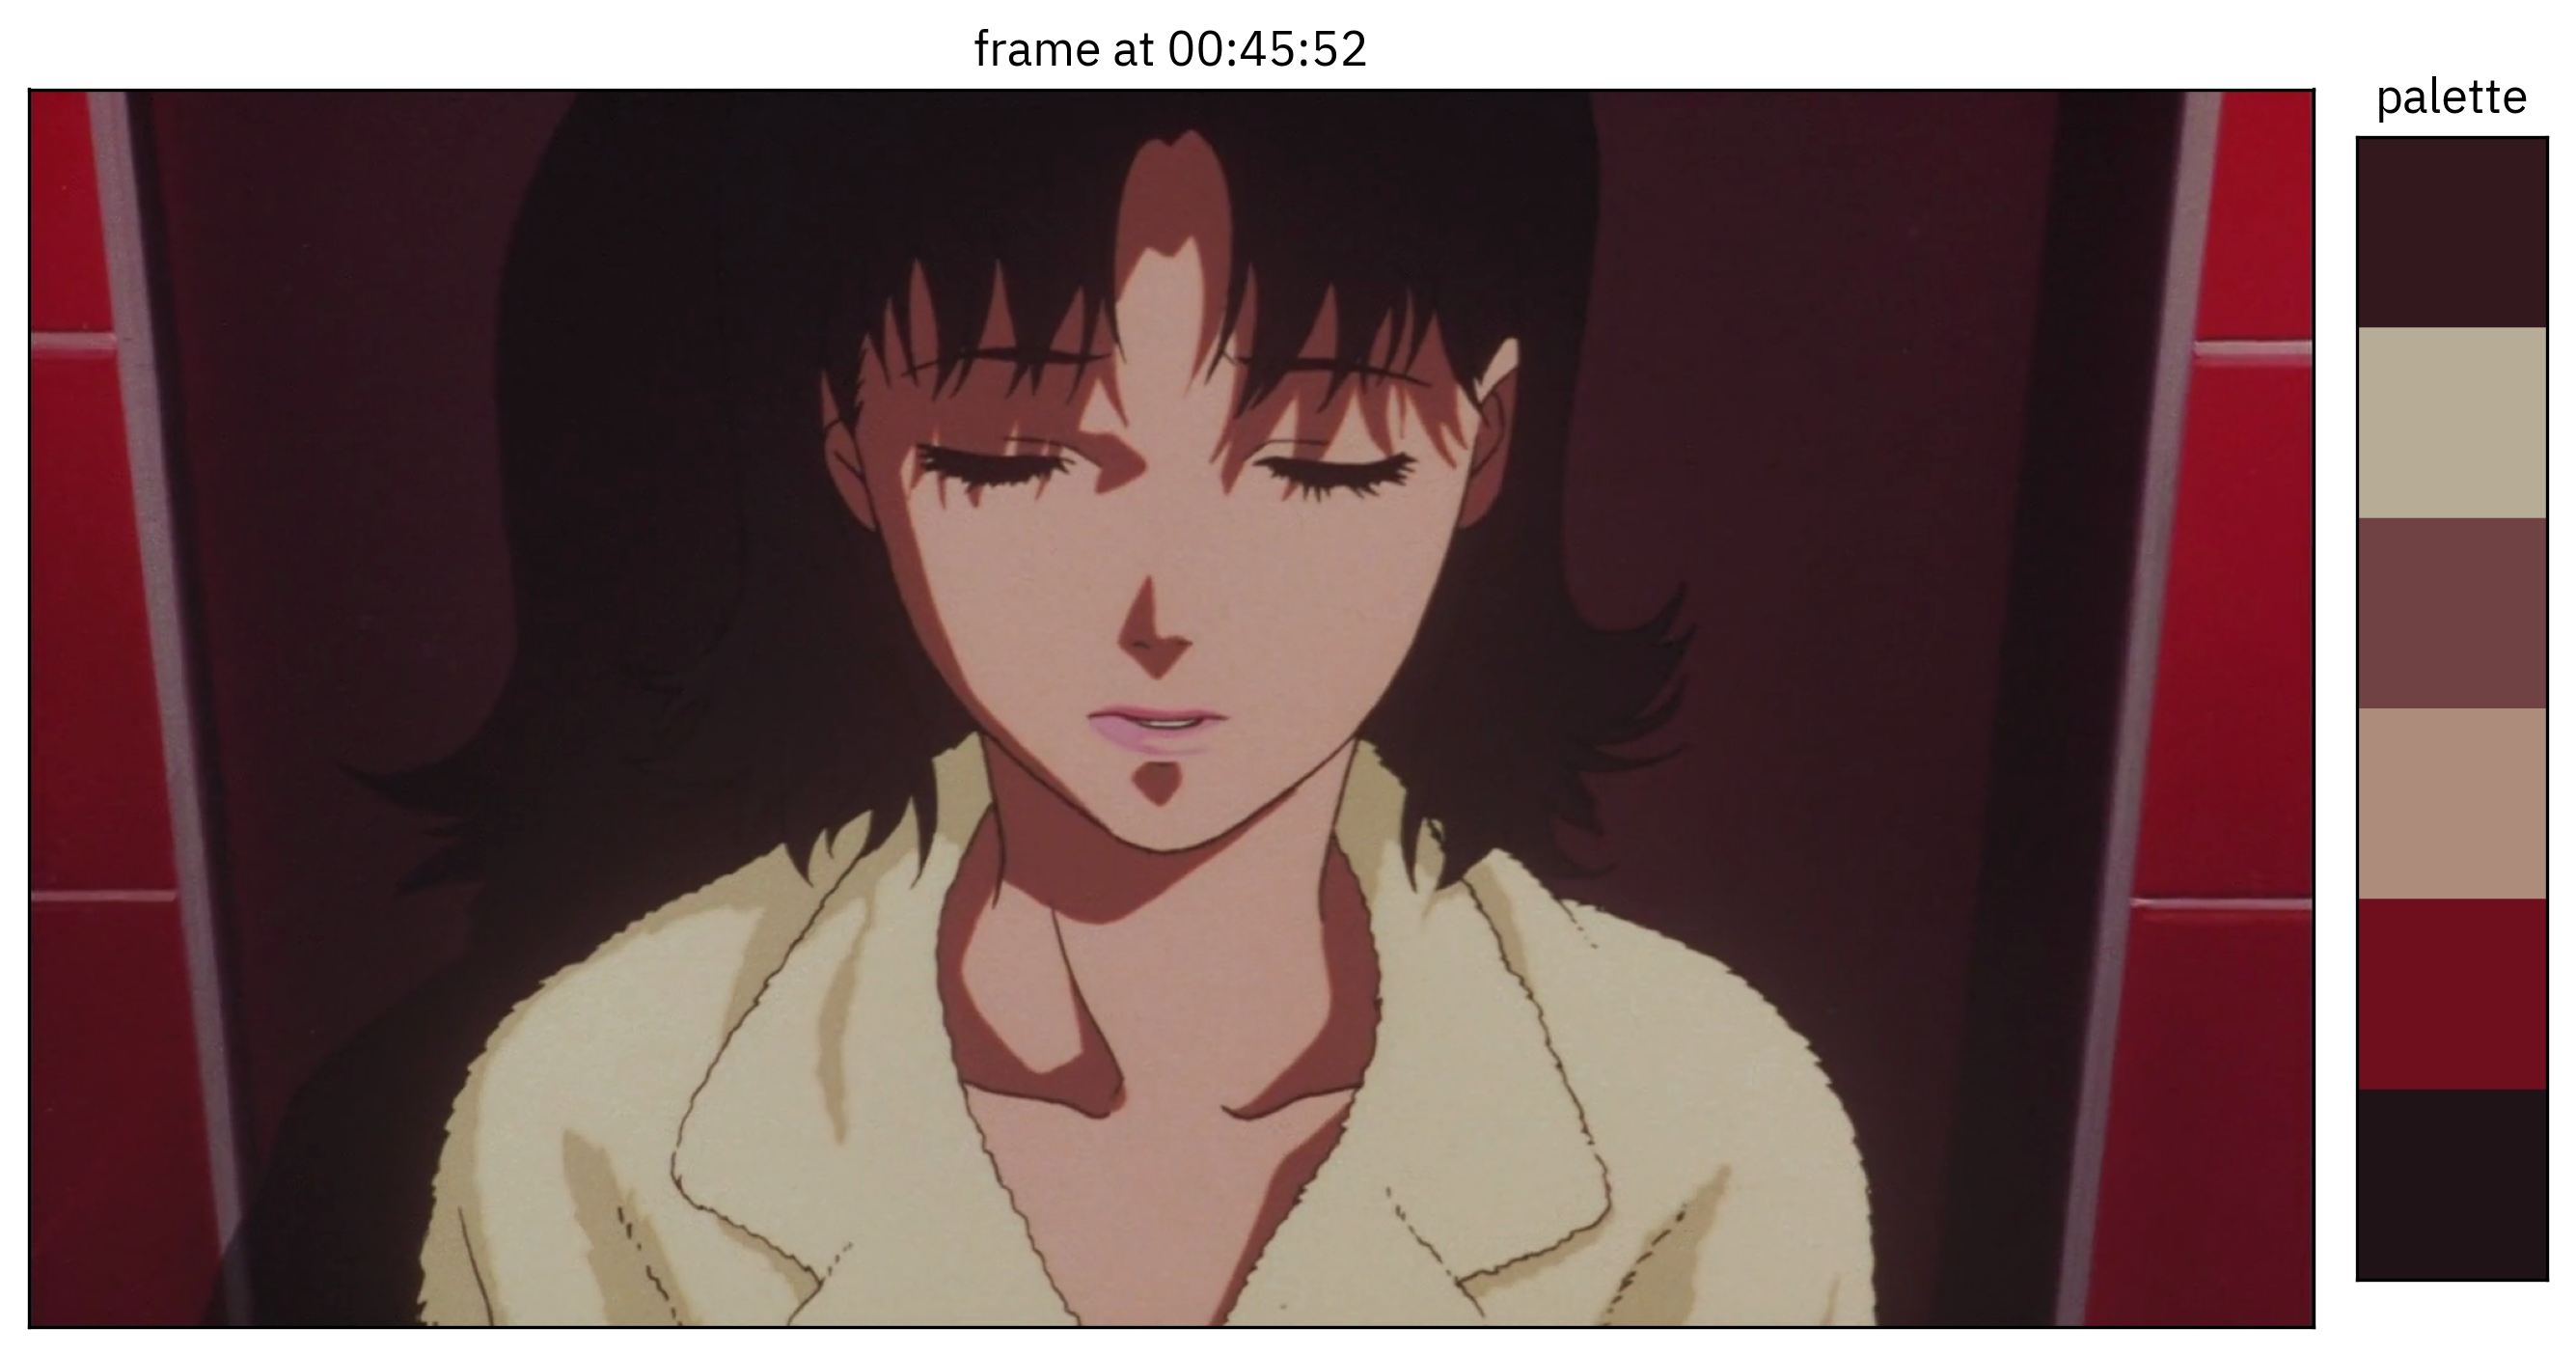

In [6]:
frame_idx = 66_000

frame = video[frame_idx]
frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)

palette = palettes[frame_idx // 6]
palette = np.broadcast_to(palette[:, np.newaxis, :], (6, 25_600, 3)).reshape((960, 160, 3))
palette = cv.cvtColor(palette, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(9, 6), width_ratios=(1920, 160))

axes[0].set(
    title=f"frame at {convert_timestamp(frame_idx)}",
    xticks=tuple(),
    yticks=tuple(),
)
axes[0].imshow(frame)

axes[1].set(
    title="palette",
    xticks=tuple(),
    yticks=tuple(),
)
axes[1].imshow(palette)

fig.tight_layout()

plt.show()

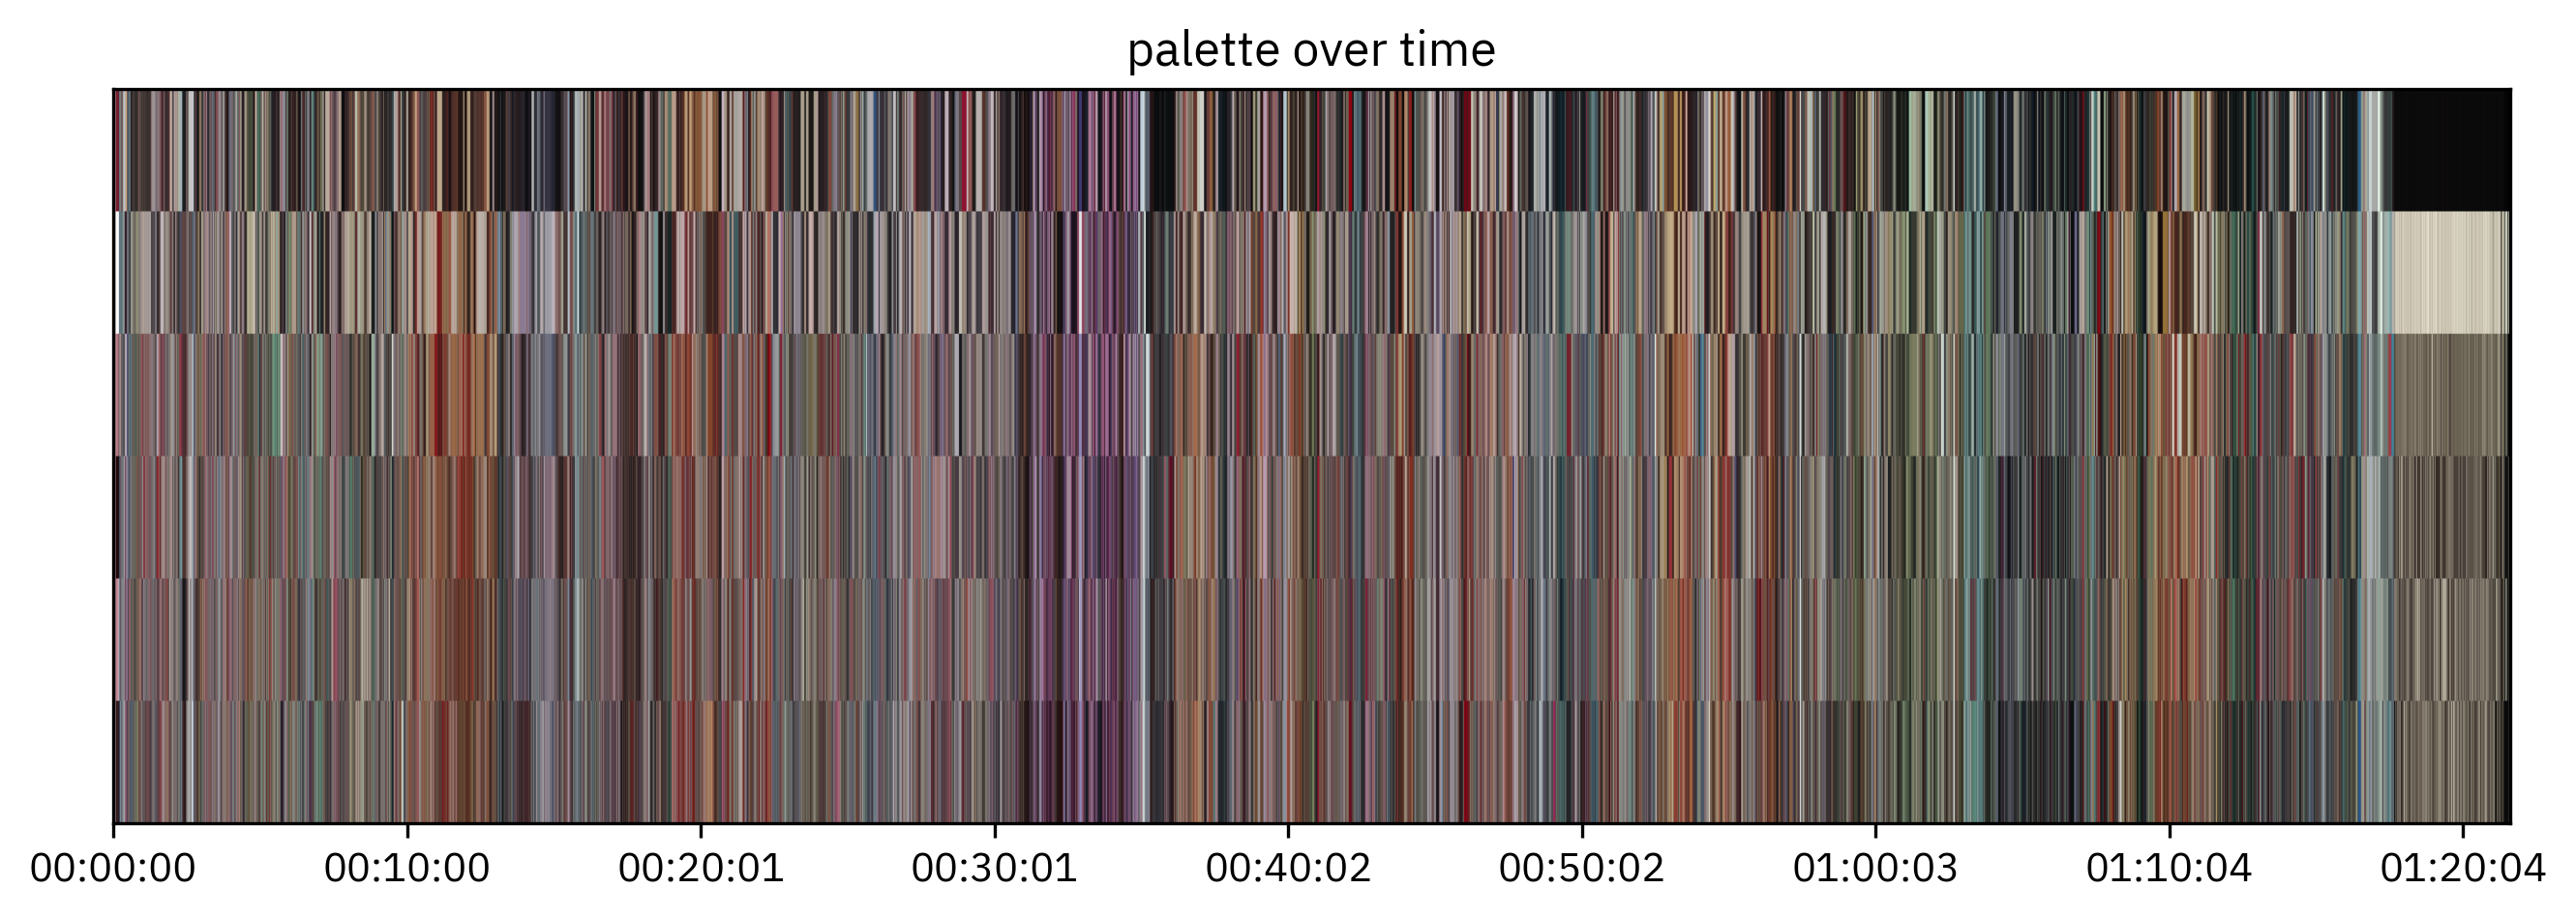

In [7]:
palettes_img = palettes
palettes_img = np.broadcast_to(palettes_img.transpose((1, 0, 2))[:, np.newaxis], (6, 1_000, num_sub_frames, 3)).reshape(6_000, num_sub_frames, 3)
palettes_img = cv.cvtColor(palettes_img, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(9, 6))

ax.set(
    title="palette over time",
    xticks=xticks,
    xticklabels=xticklabels,
    yticks=tuple(),
)
ax.imshow(palettes_img)

plt.tight_layout()
plt.show()

In [5]:
df = pd.DataFrame(index=np.arange(num_sub_frames))

In [8]:
data = {}

NameError: name 'timestamps' is not defined

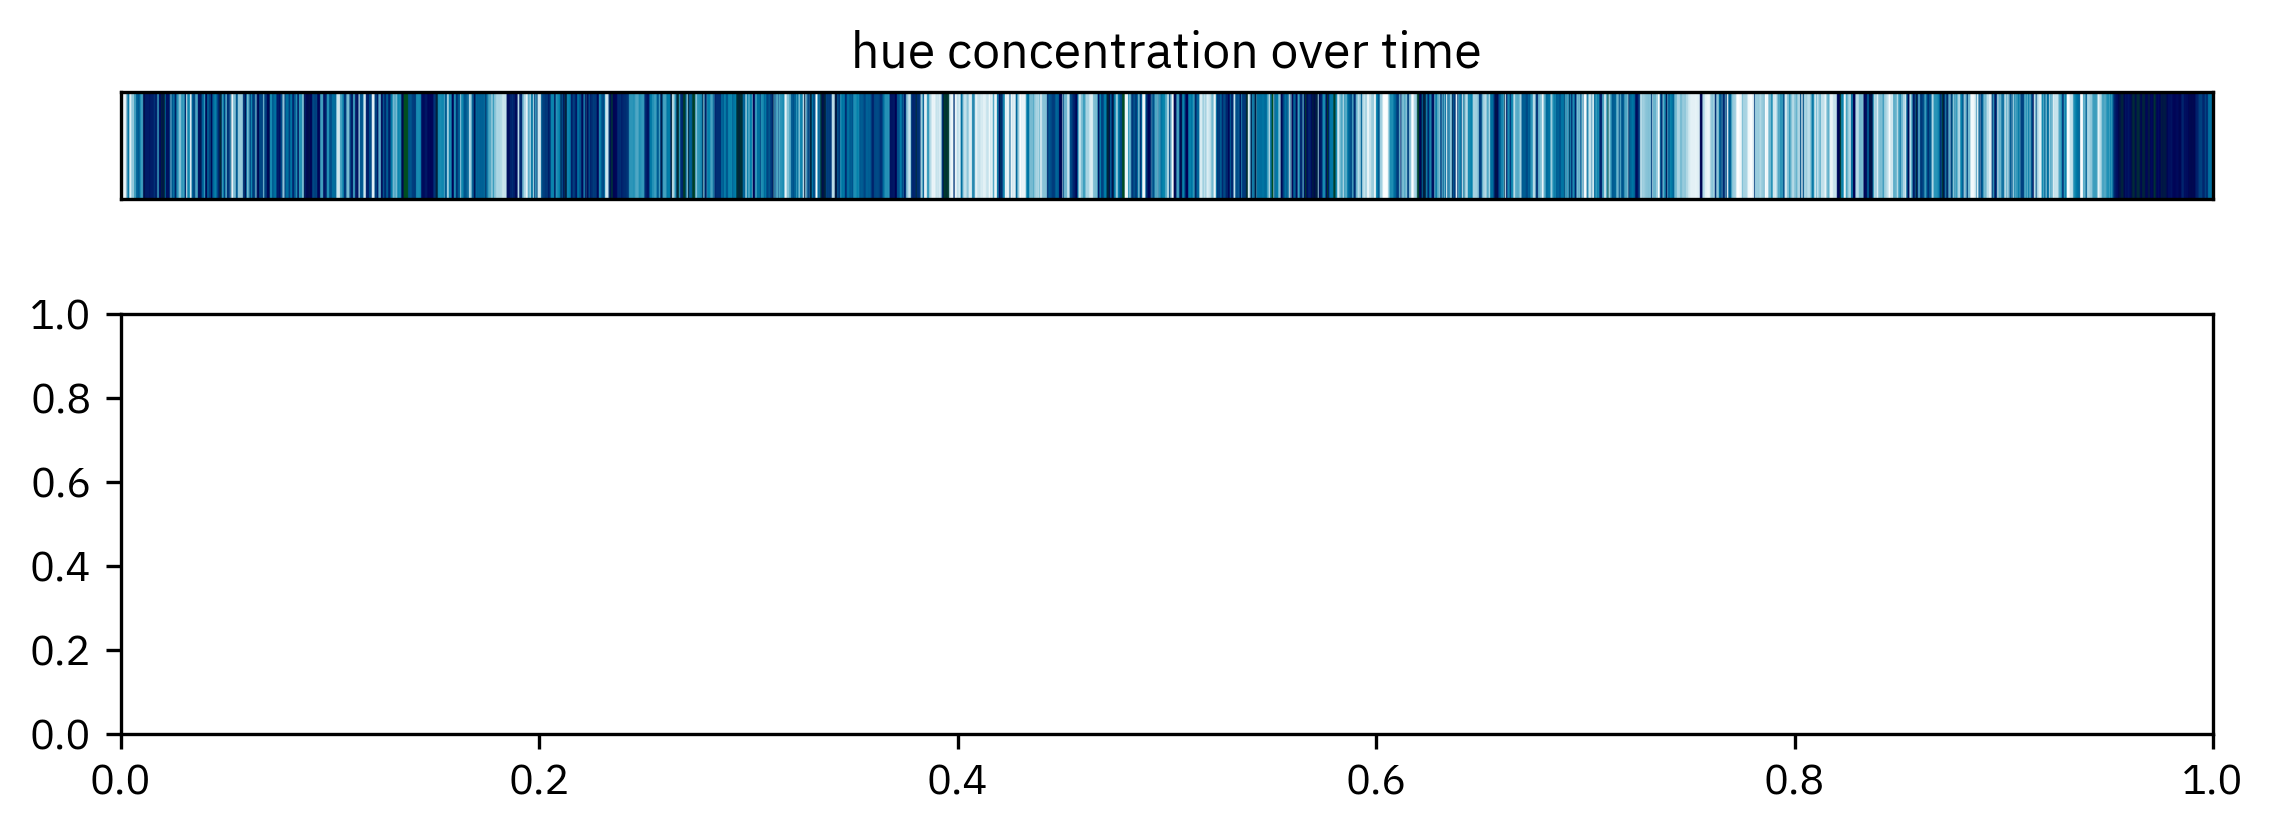

In [10]:
unit_vecs = np.pi * (np.arange(180) / 180)
unit_vecs = np.cos(unit_vecs) + 1j * np.sin(unit_vecs)

hue = hls_counts[:, 0, :180] / (video.height * video.width)
hue = (unit_vecs * hue).sum(axis=1)
hue = np.abs(hue) * 256
hue_img = np.broadcast_to(hue[np.newaxis, :], (1000, num_sub_frames)).astype(np.uint8)

fig, axes = plt.subplots(2, 1, figsize=(9, 3), height_ratios=(1, 2))

axes[0].set(
    title="hue concentration over time",
    xticks=tuple(),
    yticks=tuple(),
)
axes[0].imshow(hue_img, cmap="ocean")

axes[1].set(
    xlim=(0, num_sub_frames),
    xticks=sub_frame_idxs,
    xticklabels=timestamps,
    ylim=(0, 256),
    yticks=tuple(),
)
axes[1].plot(np.arange(num_sub_frames), smooth(hue))

plt.tight_layout()
plt.show()

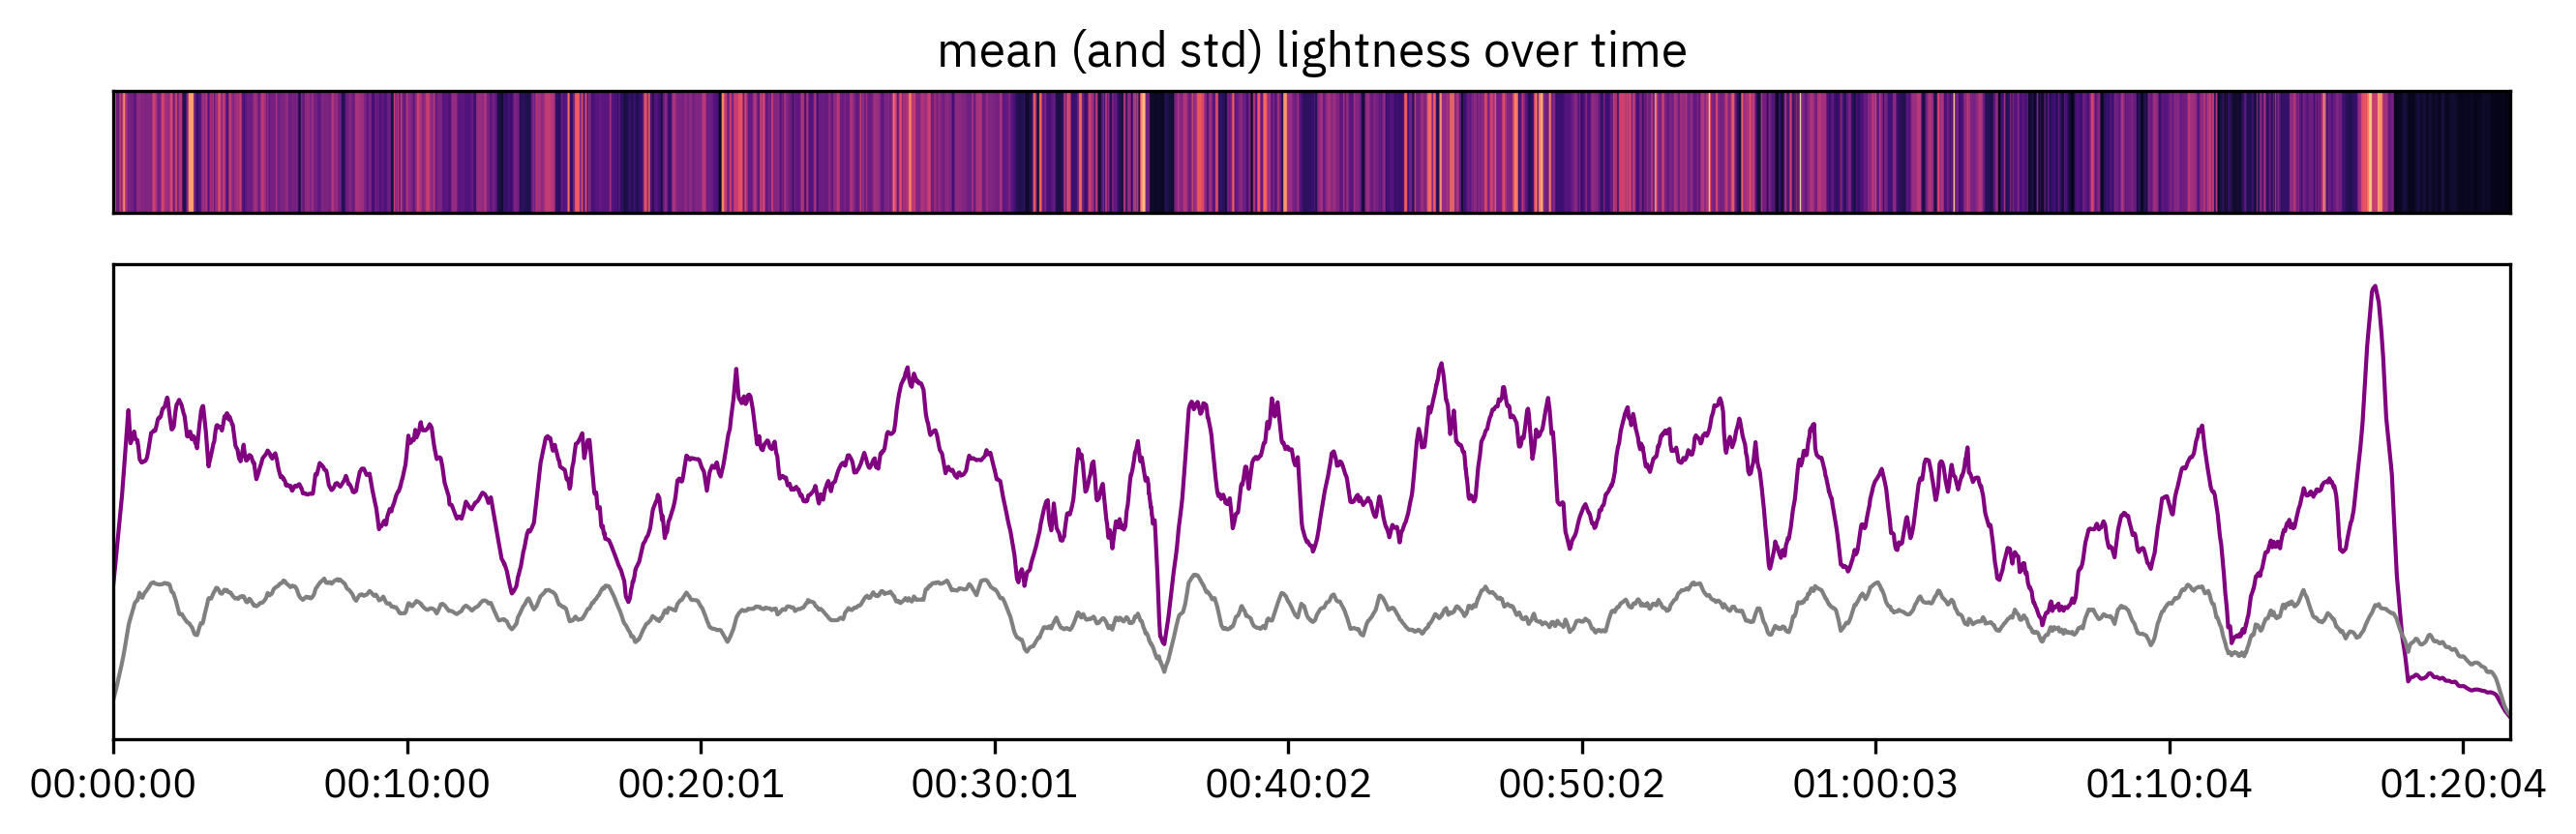

In [9]:
lightness = hls_counts[:, 1] / (video.height * video.width)
mean_lightness = (np.arange(256) / 256 * lightness).sum(axis=1)
std_lightness = (((np.arange(256) / 256) - mean_lightness[:, np.newaxis]) ** 2 * lightness).sum(axis=1) ** (1/2)
mean_lightness_img = np.broadcast_to(256 * mean_lightness[np.newaxis, :], (1000, num_sub_frames)).astype(np.uint8)

fig, axes = plt.subplots(2, 1, figsize=(9, 3), height_ratios=(1, 2))

axes[0].set(
    title="mean (and std) lightness over time",
    xticks=tuple(),
    yticks=tuple(),
)
axes[0].imshow(mean_lightness_img, cmap="magma")

axes[1].set(
    xlim=(0, num_sub_frames),
    xticks=sub_frame_idxs,
    xticklabels=timestamps,
    yticks=tuple(),
)
axes[1].plot(np.arange(num_sub_frames), smooth(mean_lightness), c="purple")
axes[1].plot(np.arange(num_sub_frames), smooth(std_lightness), c="gray")

plt.tight_layout()
plt.show()

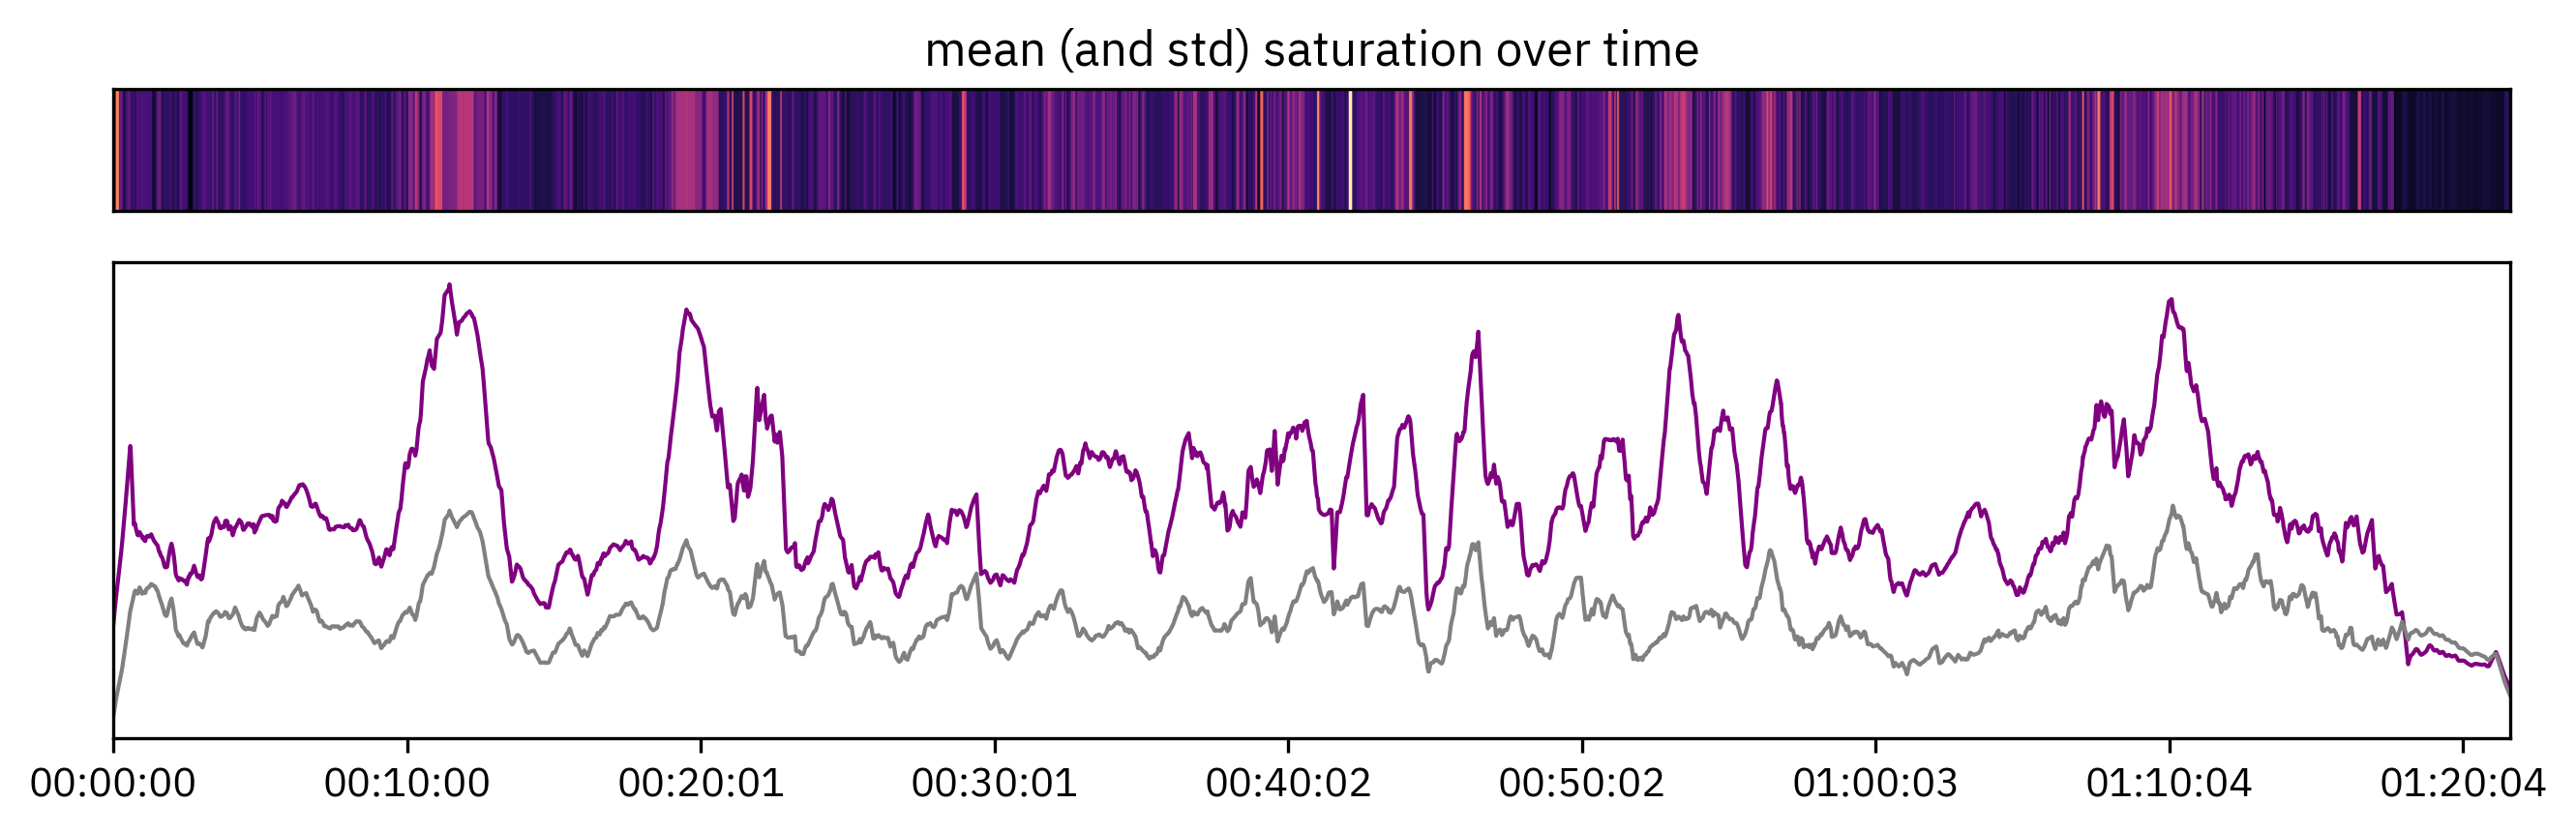

In [10]:
saturation = hls_counts[:, 2] / (video.height * video.width)
mean_saturation = (np.arange(256) / 256 * saturation).sum(axis=1)
std_saturation = (((np.arange(256) / 256) - mean_saturation[:, np.newaxis]) ** 2 * saturation).sum(axis=1) ** (1/2)
mean_saturation_img = np.broadcast_to(256 * mean_saturation[np.newaxis, :], (1000, num_sub_frames)).astype(np.uint8)

fig, axes = plt.subplots(2, 1, figsize=(9, 3), height_ratios=(1, 2))

axes[0].set(
    title="mean (and std) saturation over time",
    xticks=tuple(),
    yticks=tuple(),
)
axes[0].imshow(mean_saturation_img, cmap="magma")

axes[1].set(
    xlim=(0, num_sub_frames),
    xticks=sub_frame_idxs,
    xticklabels=timestamps,
    yticks=tuple(),
)
axes[1].plot(np.arange(num_sub_frames), smooth(mean_saturation), c="purple")
axes[1].plot(np.arange(num_sub_frames), smooth(std_saturation), c="gray")

plt.tight_layout()
plt.show()

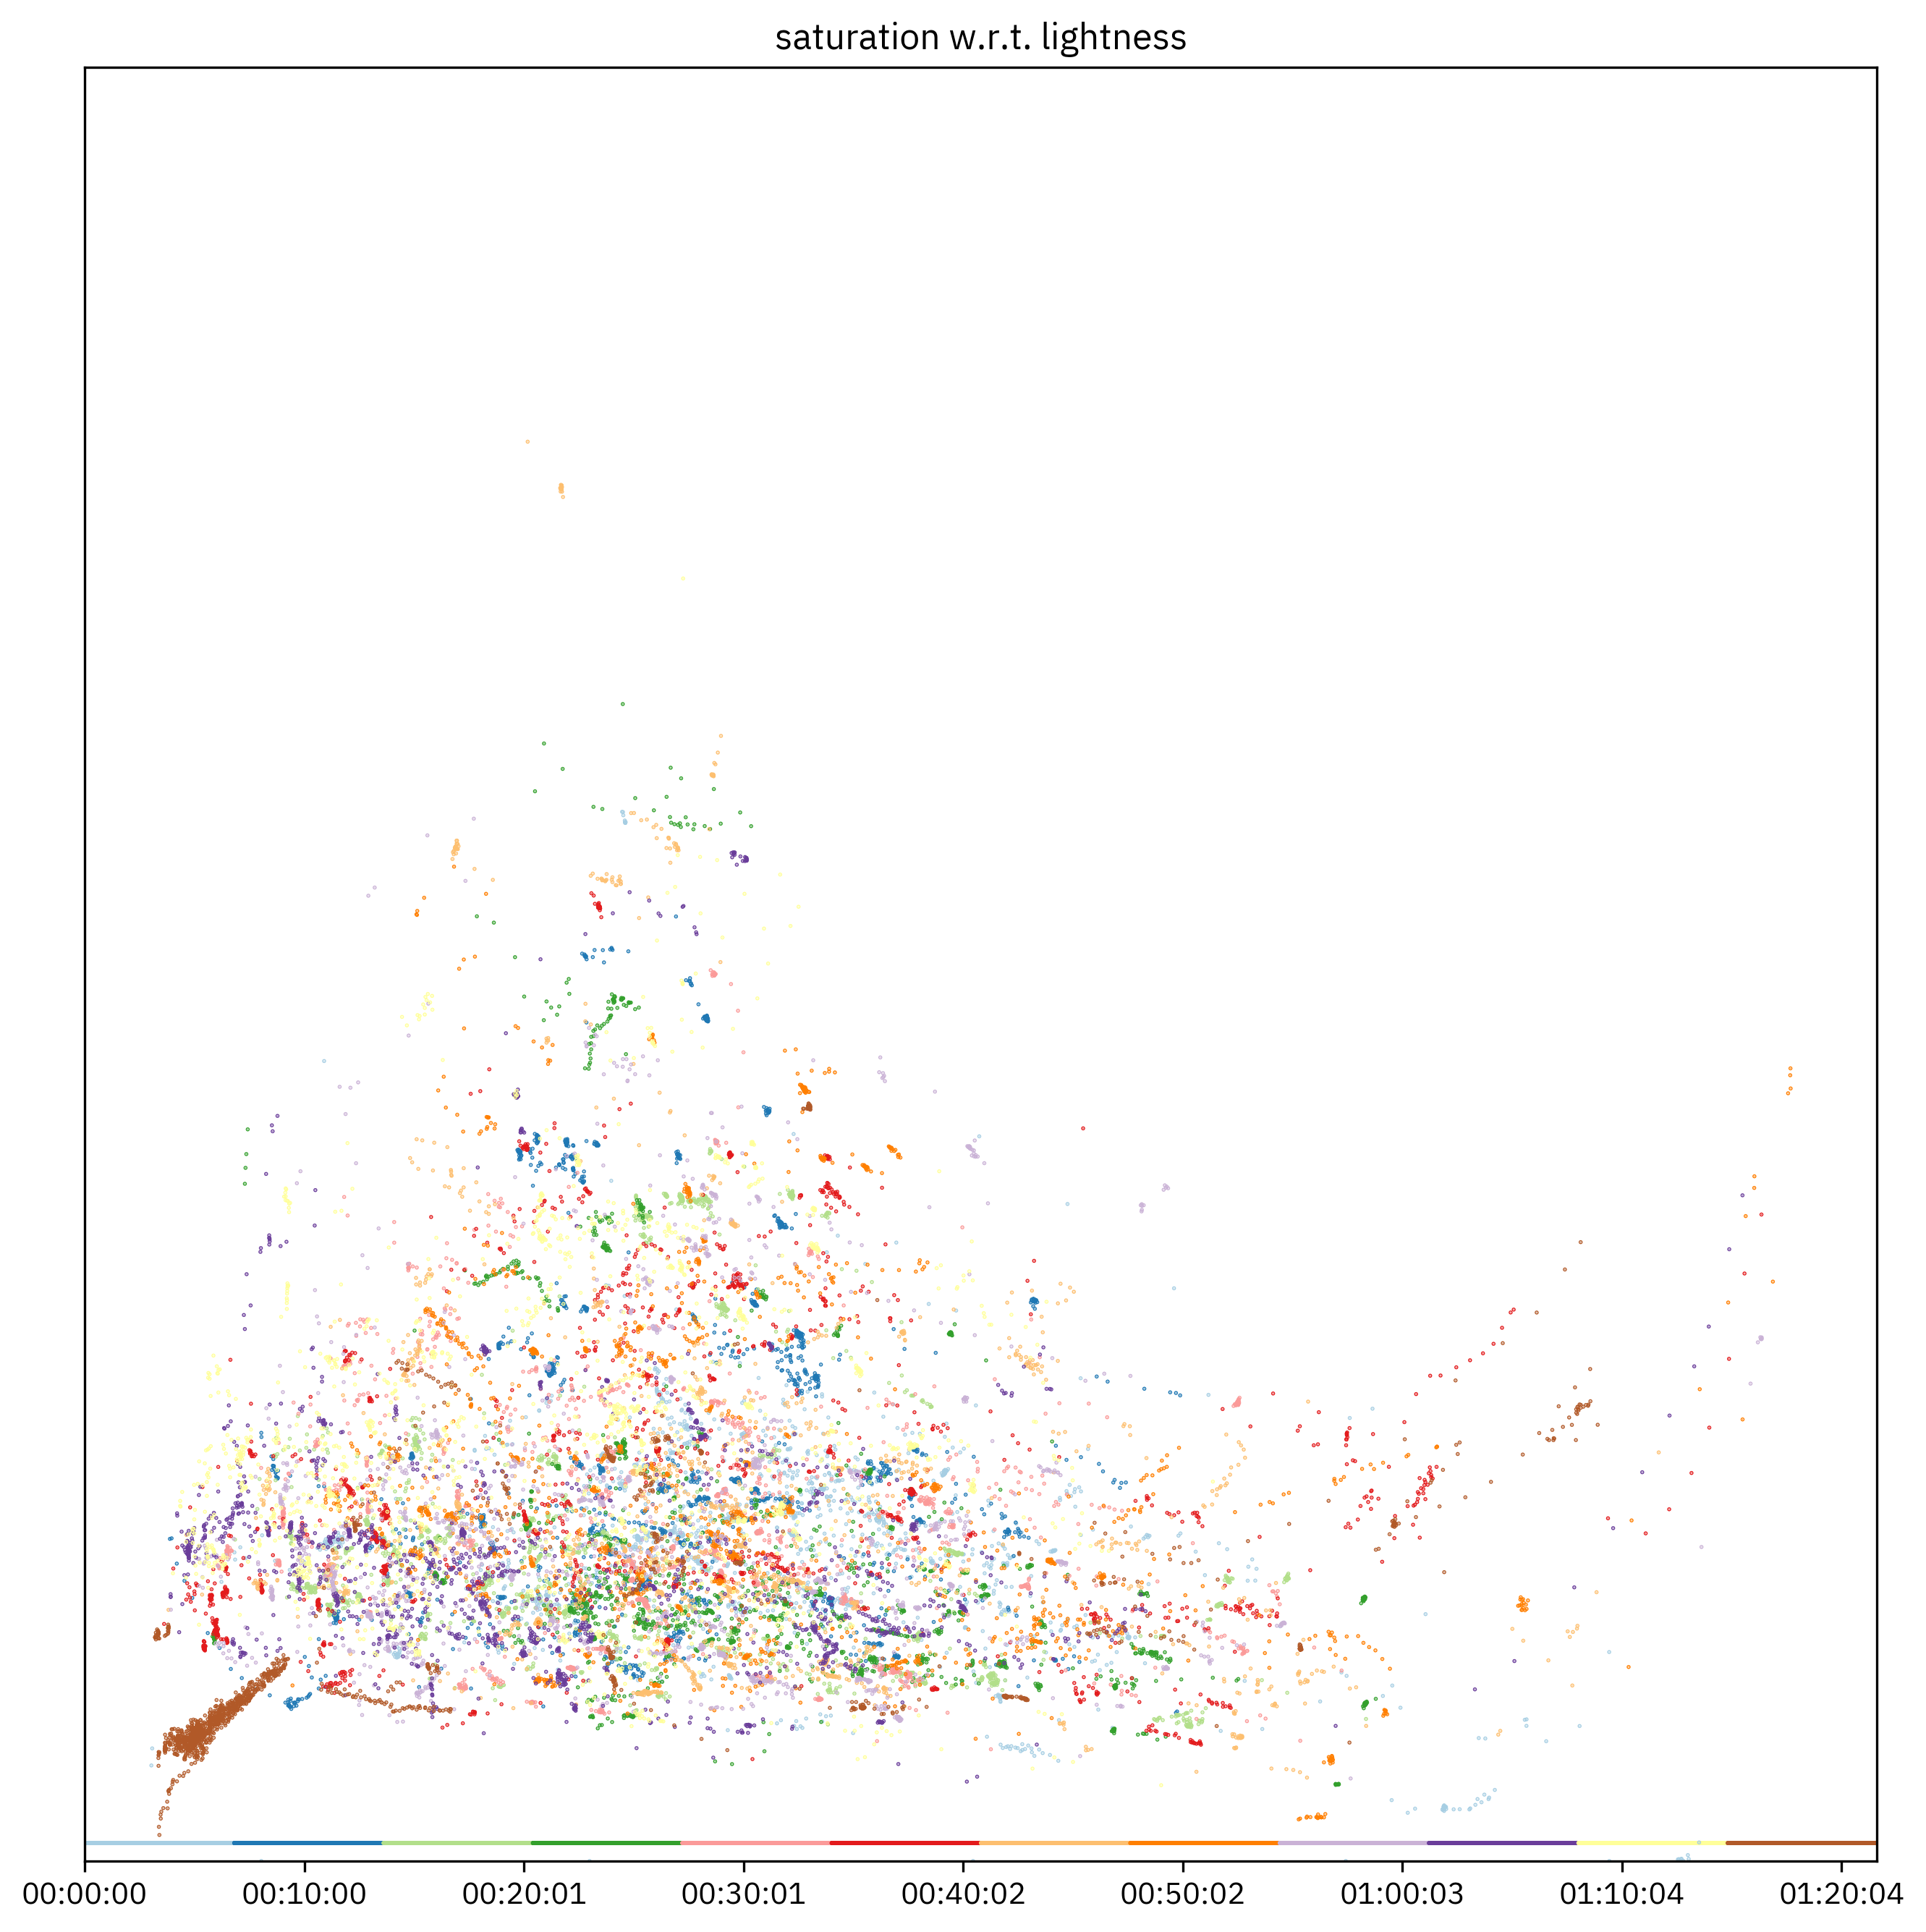

In [11]:
fig, ax = plt.subplots(figsize=(9, 9))

ax.set(
    title="saturation w.r.t. lightness",
    xlim=(0, 1),
    xticks=np.array(sub_frame_idxs) / num_sub_frames,
    xticklabels=timestamps,
    ylim=(0, 1),
    yticks=tuple(),
)
ax.scatter(
    np.arange(num_sub_frames) / num_sub_frames,
    np.ones(num_sub_frames) * 0.01,
    s=0.1,
    c=np.arange(num_sub_frames),
    cmap="Paired",
)
ax.scatter(
    mean_lightness,
    mean_saturation,
    s=0.1,
    c=np.arange(num_sub_frames),
    cmap="Paired",
)

plt.tight_layout()
plt.show()

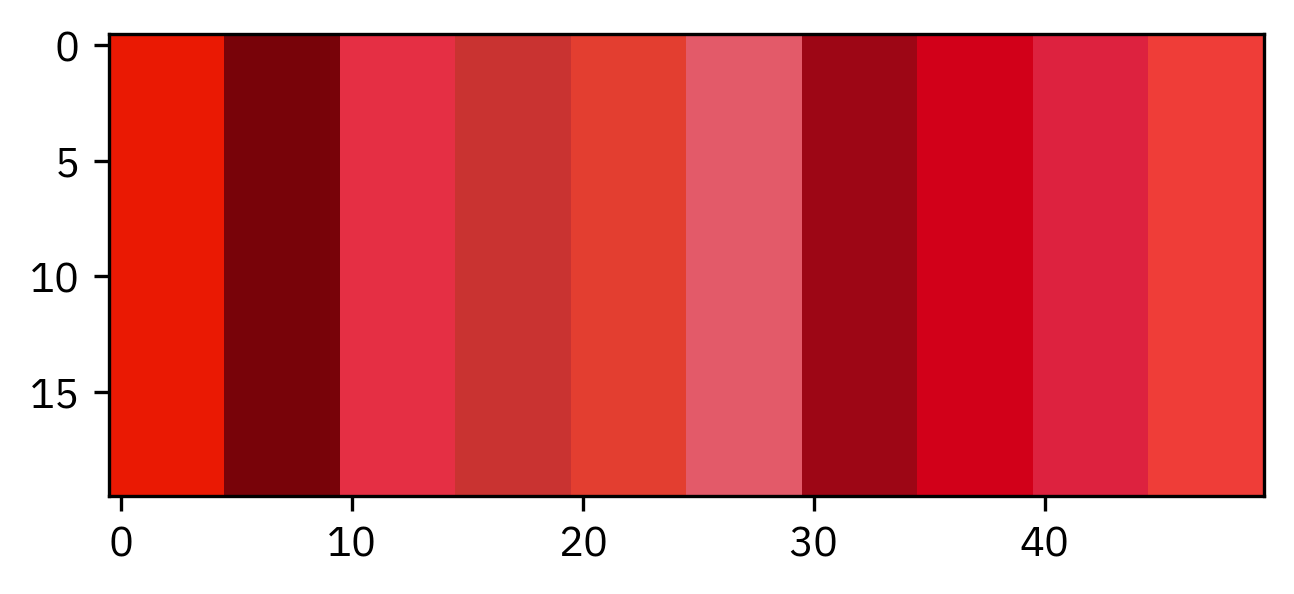

In [12]:
def is_red(c):
    assert c.shape == (3,) and c.dtype == np.uint8

    c = cv.cvtColor(c[np.newaxis, np.newaxis], cv.COLOR_BGR2HLS)[0, 0]
    hue, lightness, saturation = c

    flag = (
        (hue < 5 or hue >= 175)
        and (32 < lightness < 160)
        and saturation >= 128
    )

    return flag


out = []

while len(out) < 10:
    c = (np.random.random(size=3) * 256).astype(np.uint8)

    if is_red(c):
        out.append(c)

out = np.stack(out, axis=0)
out = np.broadcast_to(out[:, np.newaxis], (10, 100, 3)).reshape(50, 20, 3).transpose((1, 0, 2))
out = cv.cvtColor(out, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(5, 2))
ax.imshow(out)
plt.show()

In [ ]:
red_mask = palette
red_mask = cv.cvtColor(red_mask, cv.COLOR_BGR2HLS)
red_mask = (
    ((red_mask[..., 0] < 5) | (red_mask[..., 0] >= 175))
    & (red_mask[..., 1] >= 32) & (red_mask[..., 1] < 160)
    & (red_mask[..., 2] >= 128)
)
red_score = (red_mask * ((np.arange(6) + 1) ** 0.5)[::-1]).sum(axis=1)

array([0., 0., 0., ..., 0., 0., 0.], shape=(19589,))

In [24]:
import librosa

y, sr = librosa.load(input_dir / "anime.wav", sr=None)
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8_000)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

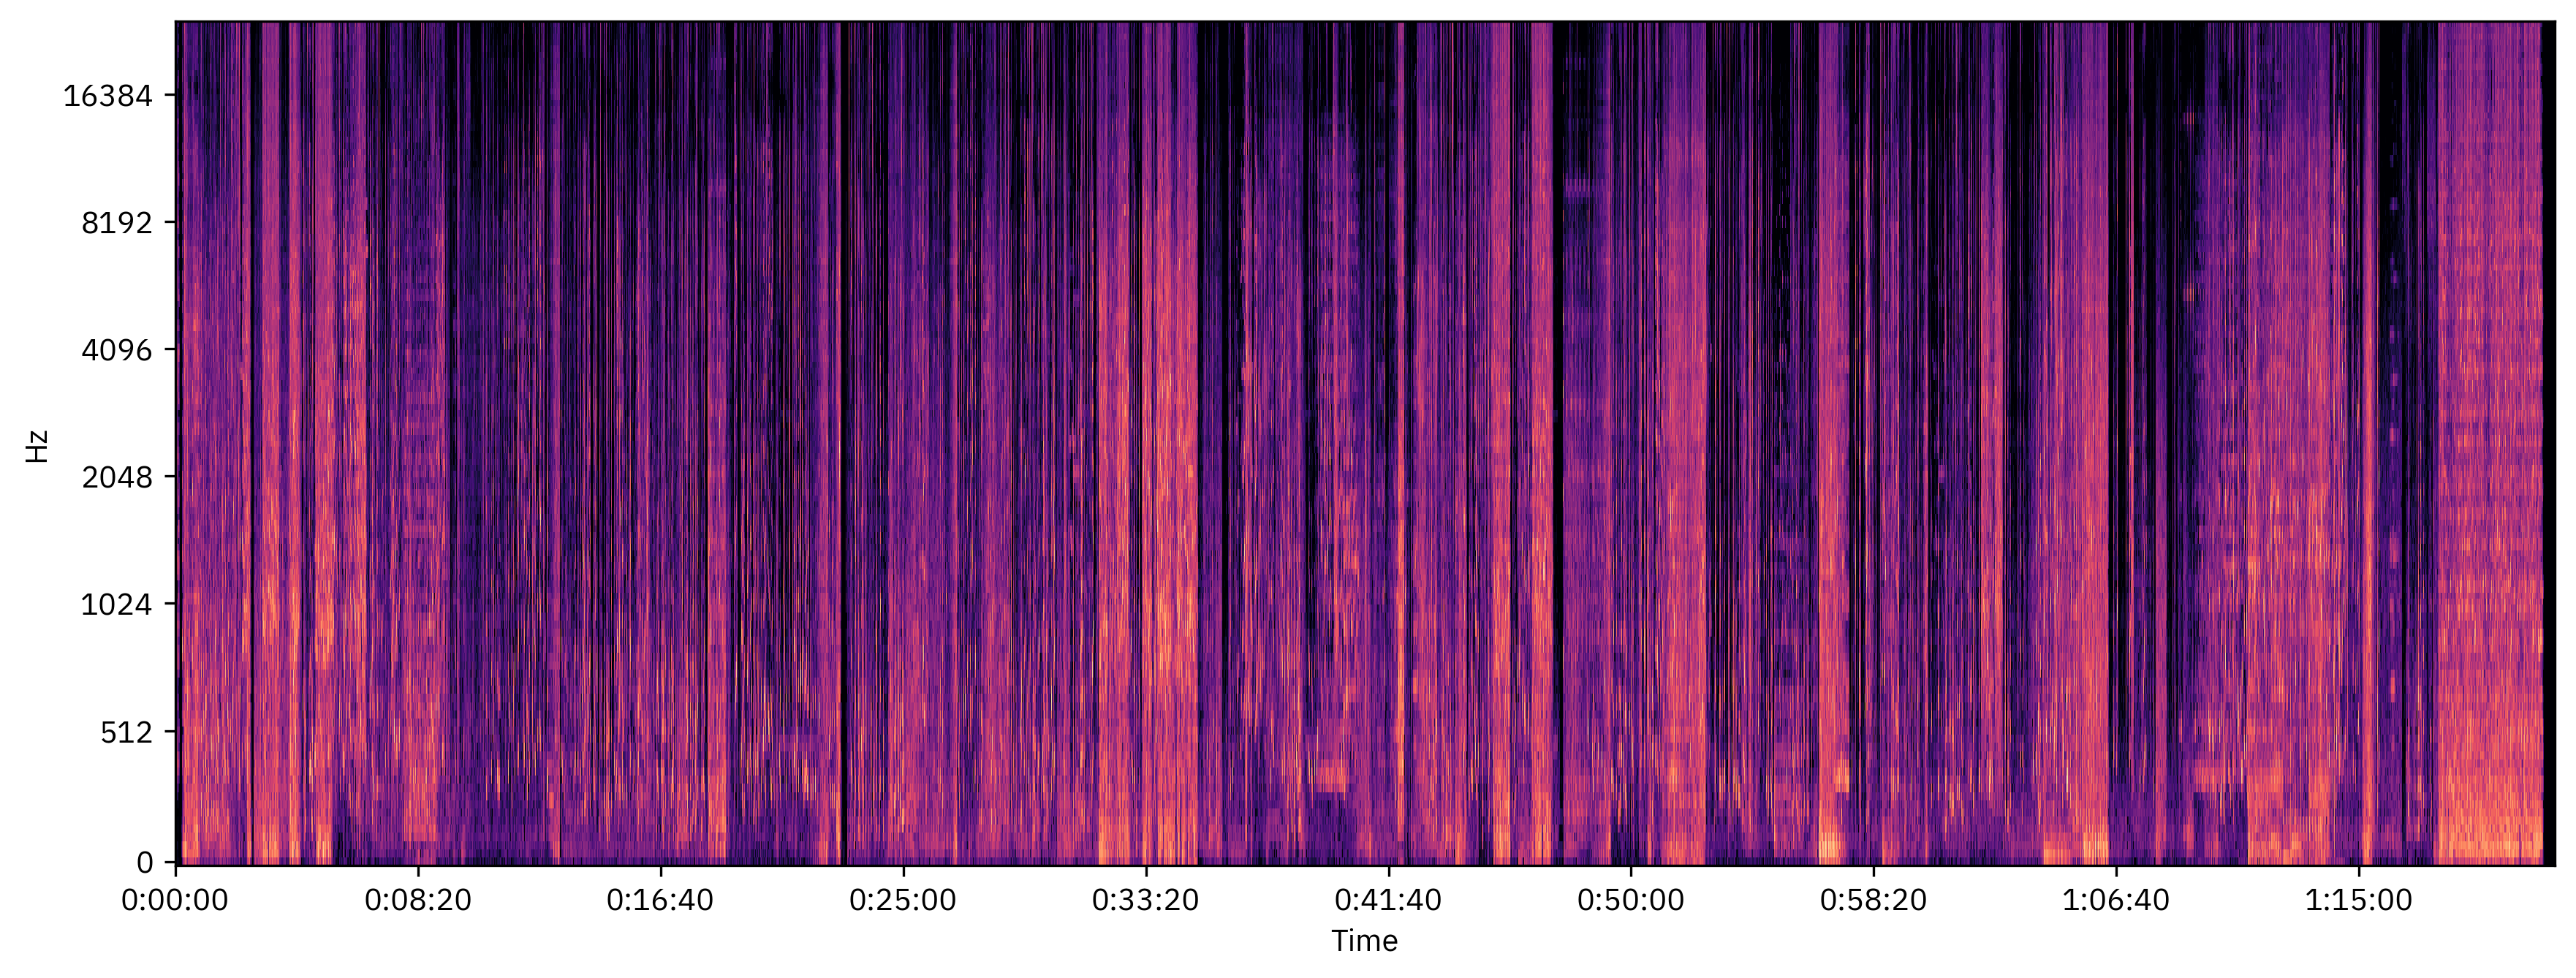

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
librosa.display.specshow(mel_spec_db, x_axis="time", y_axis="mel", sr=sr)
plt.show()

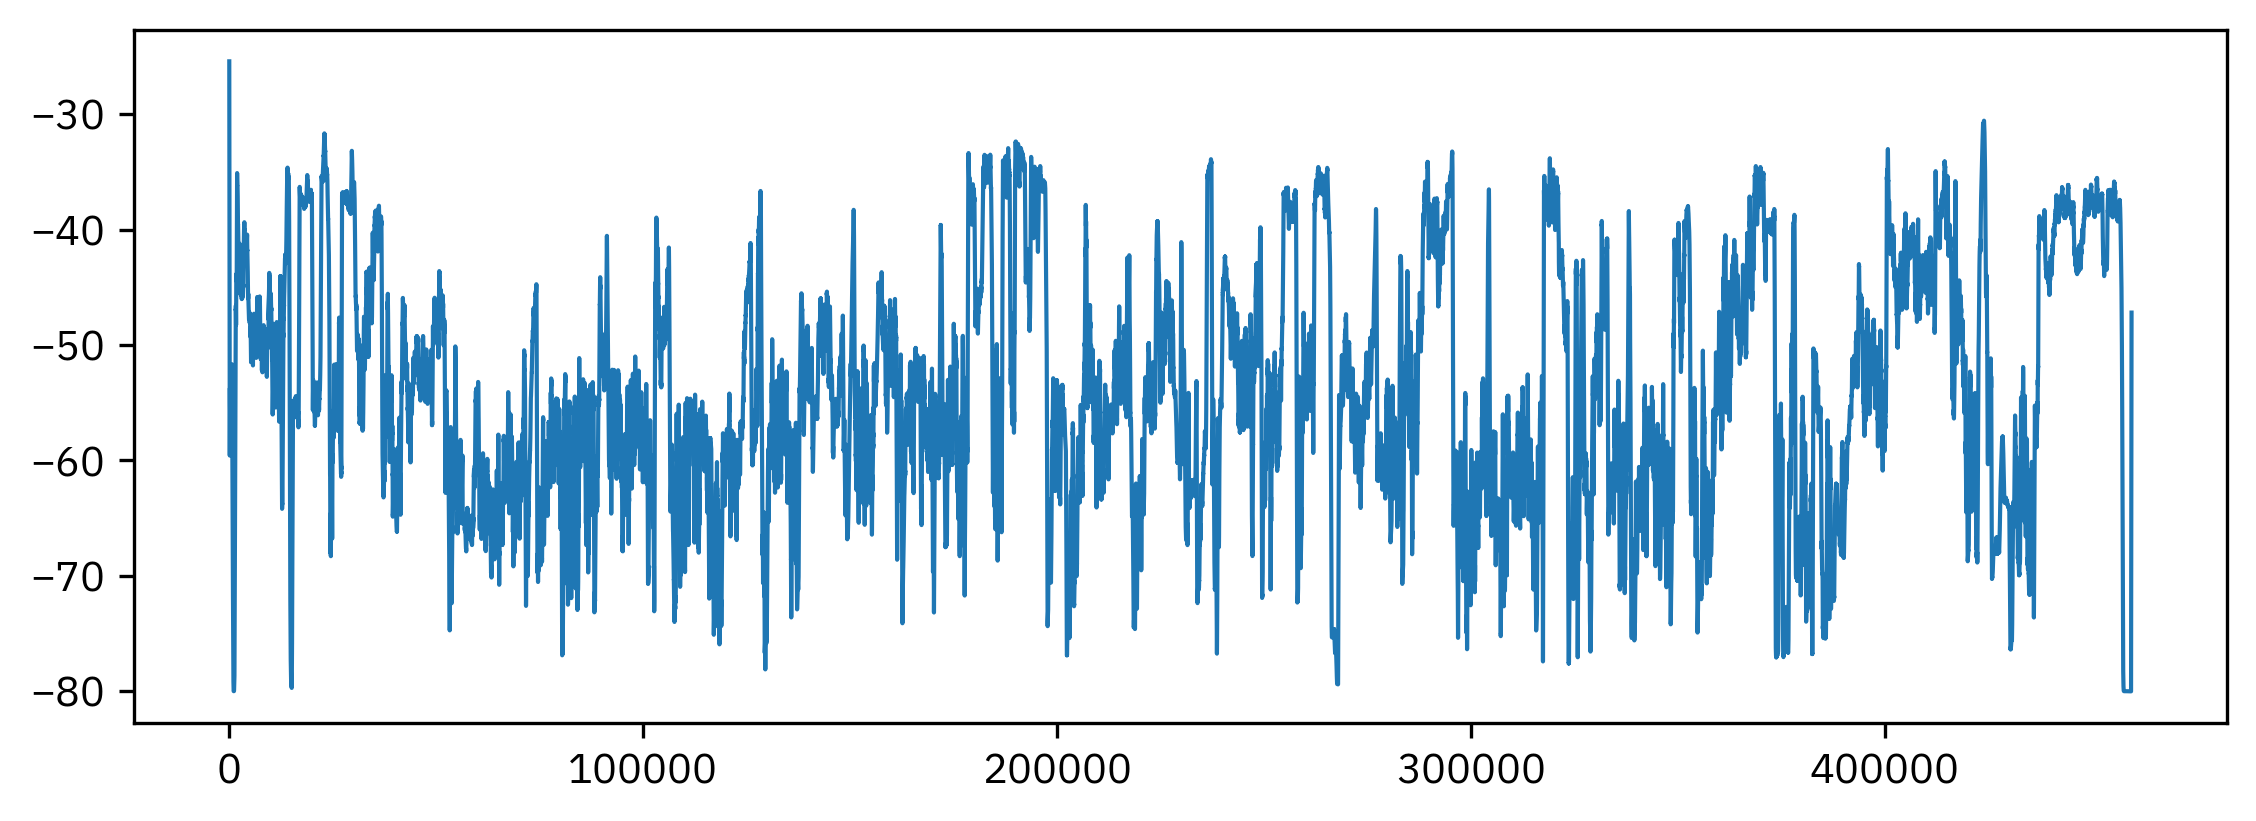

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(np.arange(459593), smooth(mel_spec_db[:106].mean(axis=0)))
plt.show()

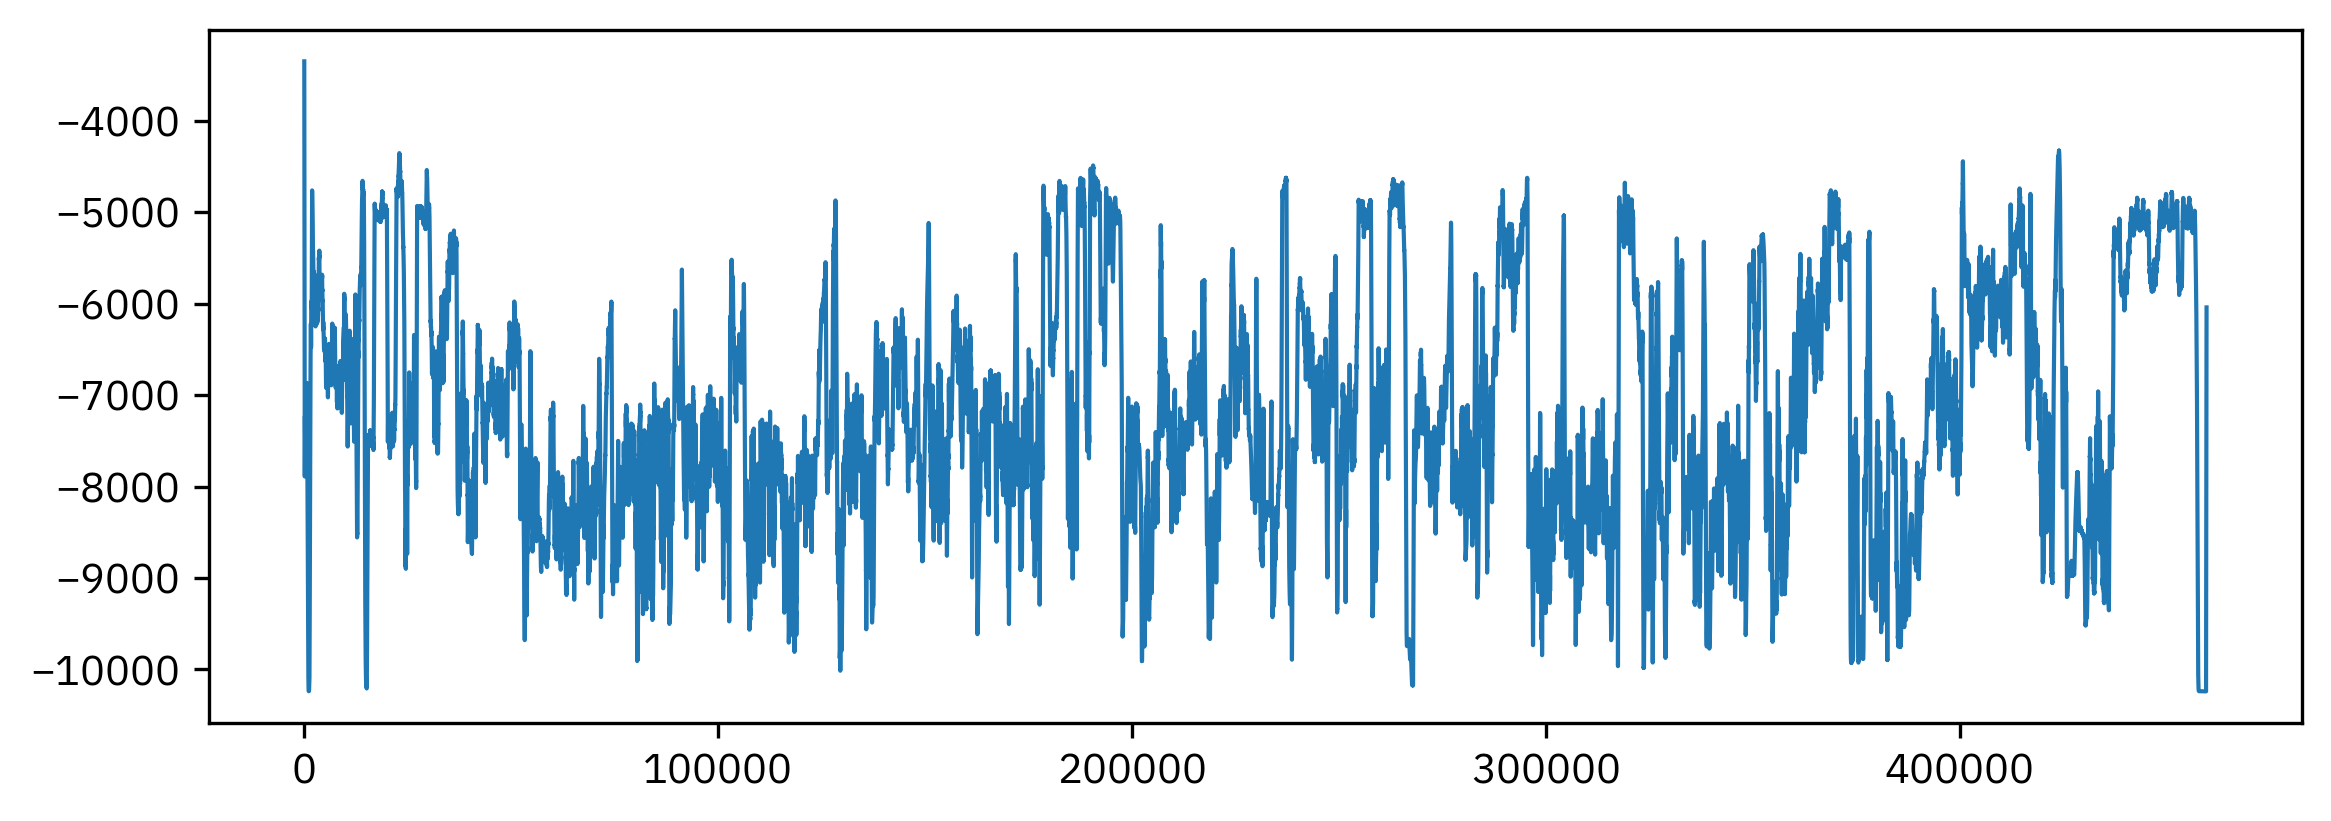

In [39]:
m = mel_spec_db
# m = (m.T * np.arange(128)).sum(axis=1) / m.sum(axis=0)
m = mel_spec_db.sum(axis=0)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(np.arange(459593), smooth(m))
plt.show()